In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv("Customer_Transactions.csv",usecols=["age","annual_income","spending_score","churned"])

In [5]:
df.sample(5)

,age,annual_income,spending_score,churned
3927,54,155456,58,0
4969,57,79690,44,0
6181,41,125524,69,0
5890,65,99962,36,0
6967,27,41013,52,0


In [6]:
df.isnull().sum()

age               0
annual_income     0
spending_score    0
churned           0
dtype: int64

In [7]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [8]:
X.sample(5)

,age,annual_income,spending_score
6233,69,38672,28
4802,27,38875,29
8138,38,51385,13
1163,37,52512,72
9801,55,119205,13


In [9]:
y.sample()

7176    1
Name: churned, dtype: int64

In [10]:
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.head()

,age,annual_income,spending_score
9254,36,55799,74
1561,34,28286,90
1670,18,120458,97
6087,55,178105,33
6669,57,45105,43


In [12]:
clf=DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)
y_pred=clf.predict(x_test)

In [14]:
accuracy_score(y_test,y_pred)

0.809

In [15]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.8129)

In [16]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')
kbin_annual_income=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')
kbin_spending_score=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')

In [17]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_annual_income,[1]),
     ('third',kbin_spending_score,[2])
])

In [18]:
x_train_trf=trf.fit_transform(X_train)
x_test_trf=trf.transform(x_test)

In [19]:
trf.named_transformers_['first']

,n_bins,10
,encode,'ordinal'
,strategy,'kmeans'
,quantile_method,'warn'
,dtype,None
,subsample,200000
,random_state,None


In [20]:
trf.named_transformers_['first'].bin_edges_

array([array([18.        , 23.25968247, 28.55831111, 33.52525907, 38.74678112,
              44.1853659 , 49.47719996, 54.56621045, 59.54021147, 64.77469998,
              70.        ])                                                   ],
      dtype=object)

In [21]:
output=pd.DataFrame({
    'age':X_train['age'],
    'age_trf':x_train_trf[:,0],
    'annual_income':X_train['annual_income'],
    'annual_income_trf':x_train_trf[:,1],
    'spending_score':X_train['spending_score'],
    'spending_score_trf':x_train_trf[:,2]
})

In [22]:
output['age_labels']=pd.cut(x=X_train['age'],
                           bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['ani labels']=pd.cut(x=X_train['annual_income'],
                           bins=trf.named_transformers_['second'].bin_edges_[0].tolist())
output['spendscor_label']=pd.cut(x=X_train['spending_score'],
                           bins=trf.named_transformers_['third'].bin_edges_[0].tolist())

In [23]:
output.sample(5)

,age,age_trf,annual_income,annual_income_trf,spending_score,spending_score_trf,age_labels,ani labels,spendscor_label
6057,68,9.0,109911,5.0,53,5.0,"(64.775, 70.0]","(97561.911, 113539.857]","(50.531, 60.476]"
4663,40,4.0,88158,4.0,96,9.0,"(38.747, 44.185]","(82255.07, 97561.911]","(90.467, 100.0]"
249,40,4.0,73841,3.0,75,7.0,"(38.747, 44.185]","(67894.854, 82255.07]","(70.434, 80.513]"
7902,62,8.0,39751,1.0,18,1.0,"(59.54, 64.775]","(38477.461, 53913.088]","(10.429, 20.539]"
777,67,9.0,172779,9.0,59,5.0,"(64.775, 70.0]","(160860.45, 179960.0]","(50.531, 60.476]"


In [24]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)

In [25]:
accuracy_score(y_test,y_pred2)

0.88

In [26]:
x_trf=trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy'))


np.float64(0.8850000000000001)

In [27]:
import warnings
warnings.filterwarnings('ignore')

def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_annual_income = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_spending_score = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_annual_income, [1]),
        ('third', kbin_spending_score, [2])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(X['age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:, 0], color='red')
    plt.title("After")

    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(X['annual_income'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1], color='red')
    plt.title("After")
    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(X['spending_score'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:, 2], color='red')
    plt.title("After")


    plt.show()

0.812


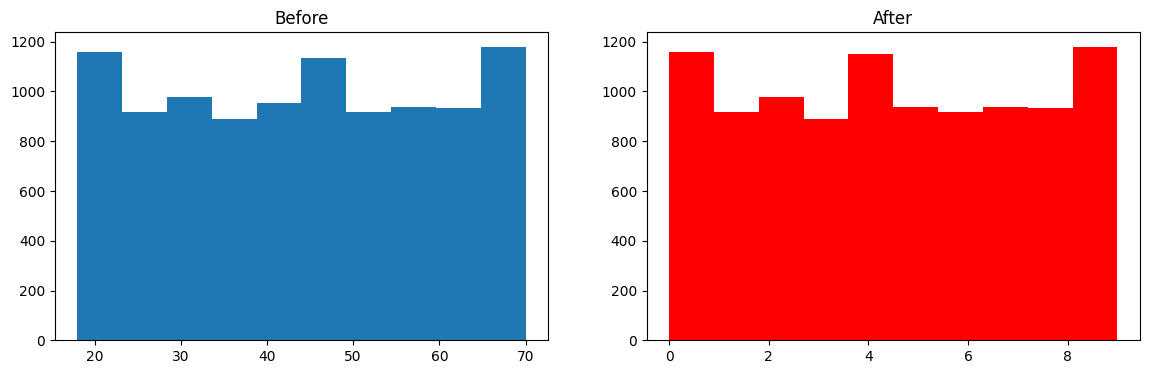

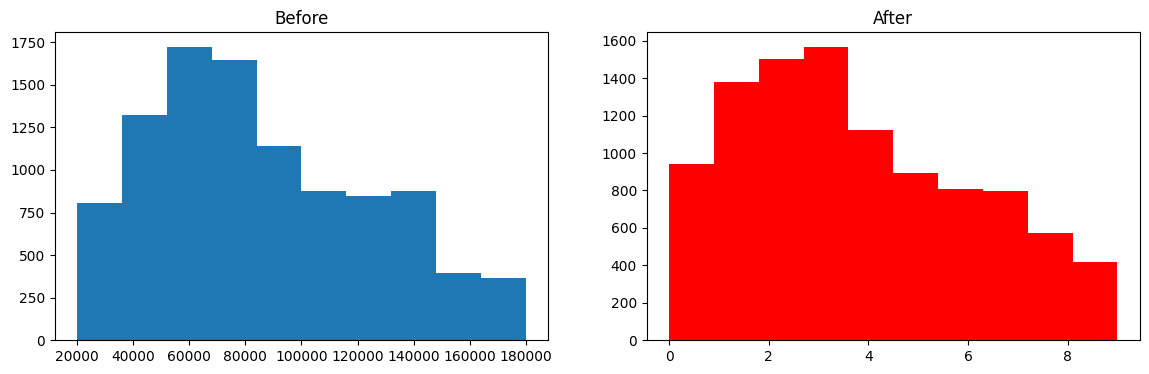

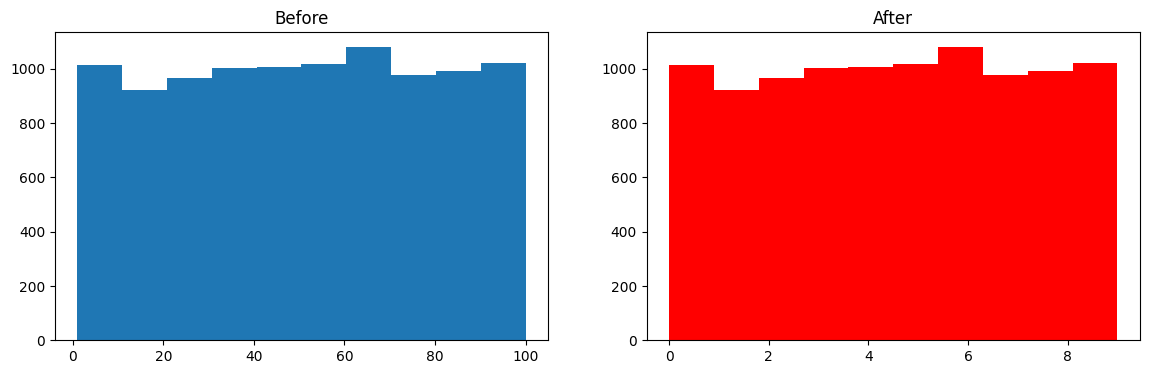

In [28]:
discretize(10,'kmeans')

0.8115


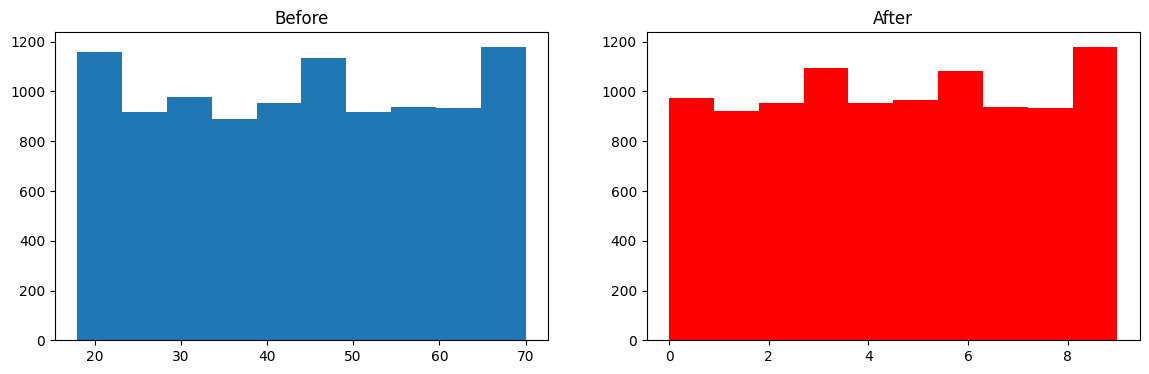

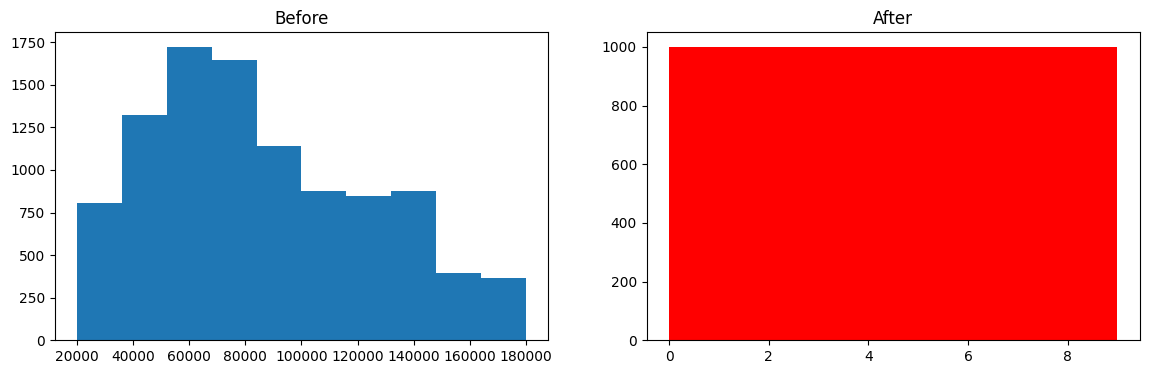

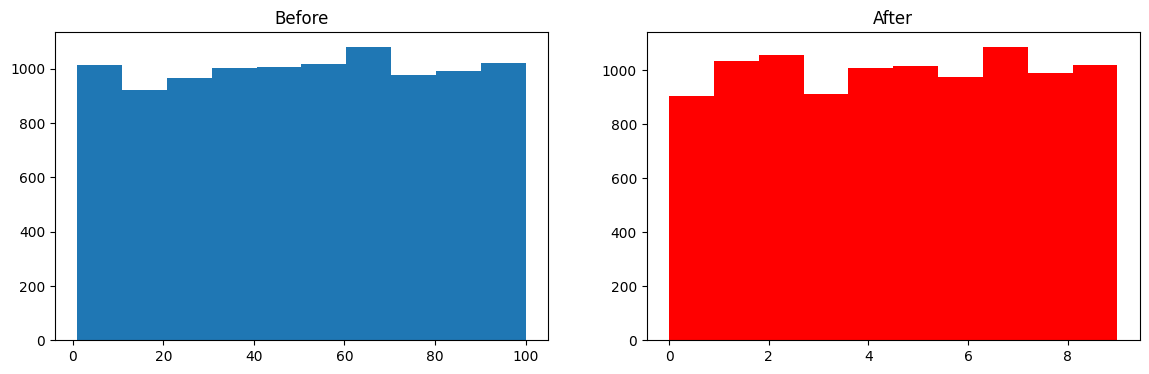

In [29]:
discretize(10,'quantile')

0.8121


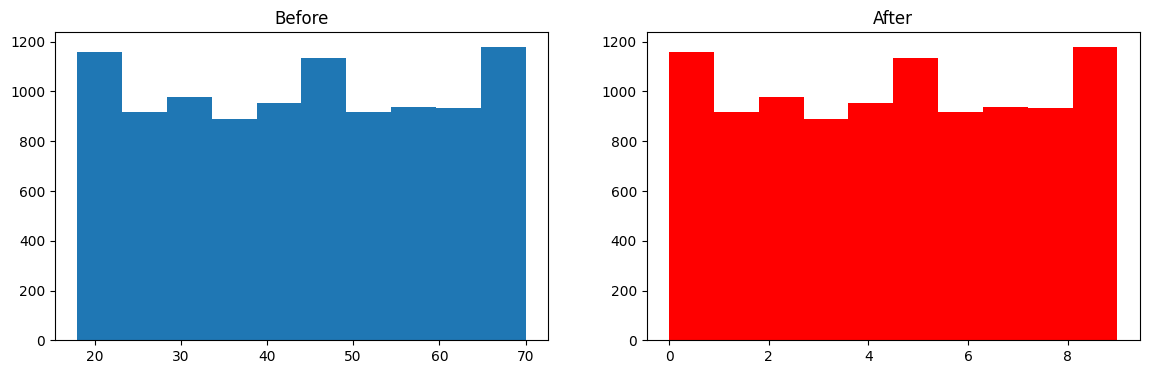

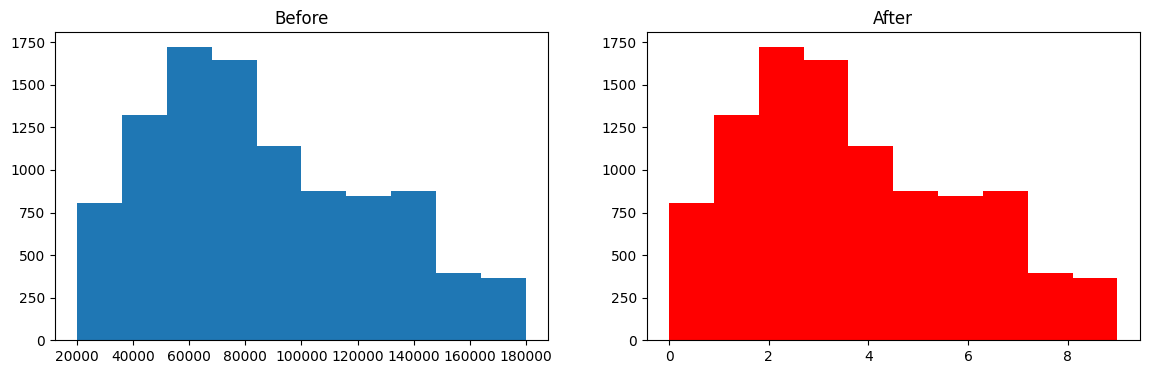

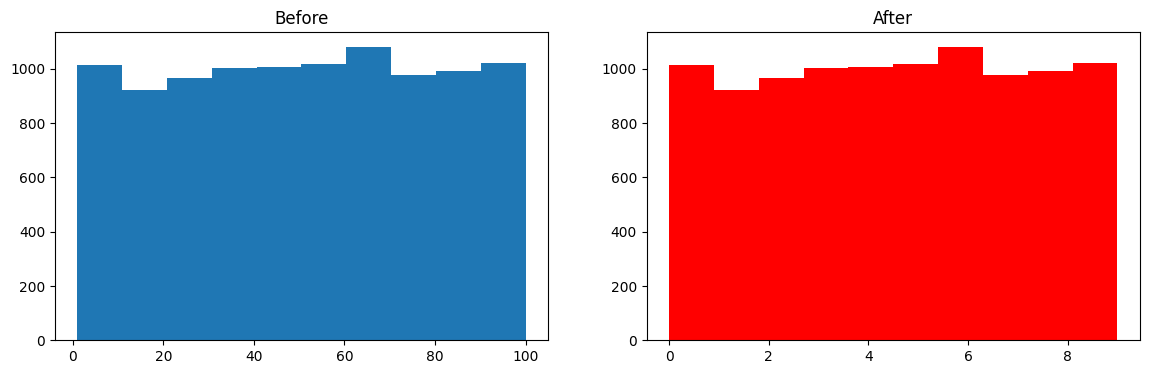

In [30]:
discretize(10,'uniform')